Before we dive into the code, here is the mental map of what we are doing. We are looking for a "Lead-Lag" relationship.

    Step A: Score the headlines (Sentiment Analysis).

    Step B: Group sentiment by day (to match stock market days).

    Step C: Merge the news data with the price data.

    Step D: Calculate the Correlation Coefficient.

In [7]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
# 1. Load the data
# Adjust the paths if your Task 1 news data is named differently
news = pd.read_csv('../data/raw/raw_analyst_ratings.csv') 
prices = pd.read_csv('../data/raw/stock_prices.csv')

# 2. Initialize VADER
analyzer = SentimentIntensityAnalyzer()

# 3. Calculate Sentiment (This might take a minute if the file is huge)
print("Analyzing sentiment...")
news['sentiment'] = news['headline'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])

# 4. Convert dates to standard format
print("Standardizing dates...")

# Use format='mixed' to handle the inconsistent strings in the news data
news['date'] = pd.to_datetime(news['date'], format='mixed', utc=True).dt.date

# Prices are usually cleaner, but we'll apply the same logic for safety
prices['Date'] = pd.to_datetime(prices['Date'], format='mixed', utc=True).dt.date

print("✅ Date conversion successful!")

Analyzing sentiment...
Standardizing dates...
✅ Date conversion successful!


Correlation Analysis (The Math)

we can calculate the correlation. This is the Pearson Correlation Coefficient ($r$).

Total trading days analyzed: 111
Pearson Correlation between Sentiment and Stock Returns: 0.2428


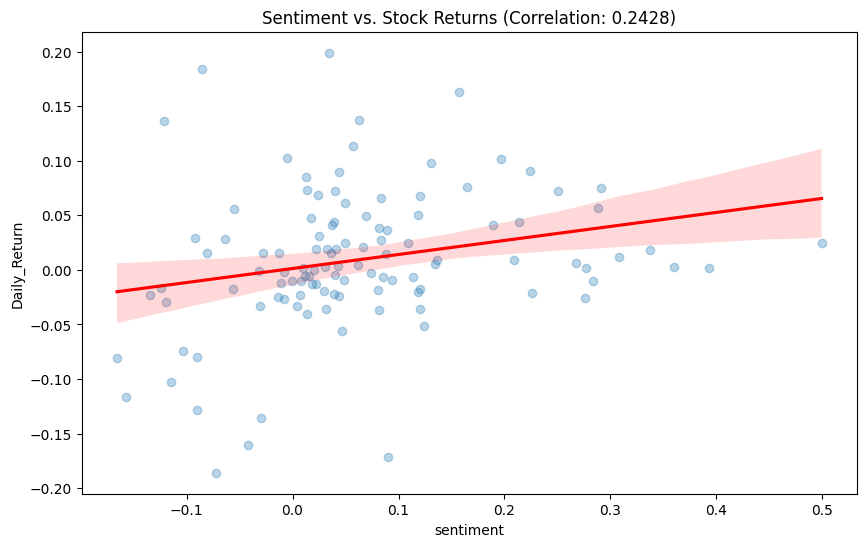

In [9]:
# 1. Group news by date to get the average "Mood" of the day
daily_sentiment = news.groupby('date')['sentiment'].mean().reset_index()

# 2. Merge with prices (Inner join ensures we only keep days where both exist)
merged_df = pd.merge(prices, daily_sentiment, left_on='Date', right_on='date', how='inner')

# 3. Calculate Returns (Percentage change in price)
# Correlation works better on "Returns" than on raw "Price"
merged_df['Daily_Return'] = merged_df['Close'].pct_change()

# 4. Drop the first row (it will be NaN after pct_change)
merged_df = merged_df.dropna(subset=['Daily_Return'])

# 5. Calculate Correlation
correlation = merged_df['sentiment'].corr(merged_df['Daily_Return'])

print(f"Total trading days analyzed: {len(merged_df)}")
print(f"Pearson Correlation between Sentiment and Stock Returns: {correlation:.4f}")

# Visualization of the relationship
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.regplot(data=merged_df, x='sentiment', y='Daily_Return', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'Sentiment vs. Stock Returns (Correlation: {correlation:.4f})')
plt.show()

In [6]:
# 1. Aggregate: Group news by date and calculate the average sentiment score for that day
daily_sentiment = news.groupby('date')['sentiment'].mean().reset_index()

# 2. Merge: Join the daily sentiment with the stock price data
# We use an 'inner' join so we only keep days where both news and stock data exist
merged_df = pd.merge(prices, daily_sentiment, left_on='Date', right_on='date', how='inner')

# 3. Calculate Daily Returns (The % change in stock price)
# We correlate sentiment with "Returns" because raw price is often too "noisy"
merged_df['Daily_Return'] = merged_df['Close'].pct_change()

# 4. Final Cleanup: Remove the first row (which becomes NaN after pct_change)
merged_df = merged_df.dropna(subset=['Daily_Return'])

# 5. The Moment of Truth: Calculate Correlation
correlation = merged_df['sentiment'].corr(merged_df['Daily_Return'])

print(f"Analysis complete across {len(merged_df)} overlapping days.")
print(f"Pearson Correlation (Sentiment vs Returns): {correlation:.4f}")

# Display the first few rows of the combined data
merged_df[['Date', 'sentiment', 'Close', 'Daily_Return']].head()

Analysis complete across 111 overlapping days.
Pearson Correlation (Sentiment vs Returns): 0.2428


,Date,sentiment,Close,Daily_Return
1,2020-01-03,-0.091941,29.534000,0.029633
2,2020-01-06,0.041344,30.102667,0.019255
3,2020-01-07,0.081310,31.270666,0.038801
4,2020-01-08,0.069628,32.809334,0.049205
5,2020-01-09,0.039438,32.089333,-0.021945


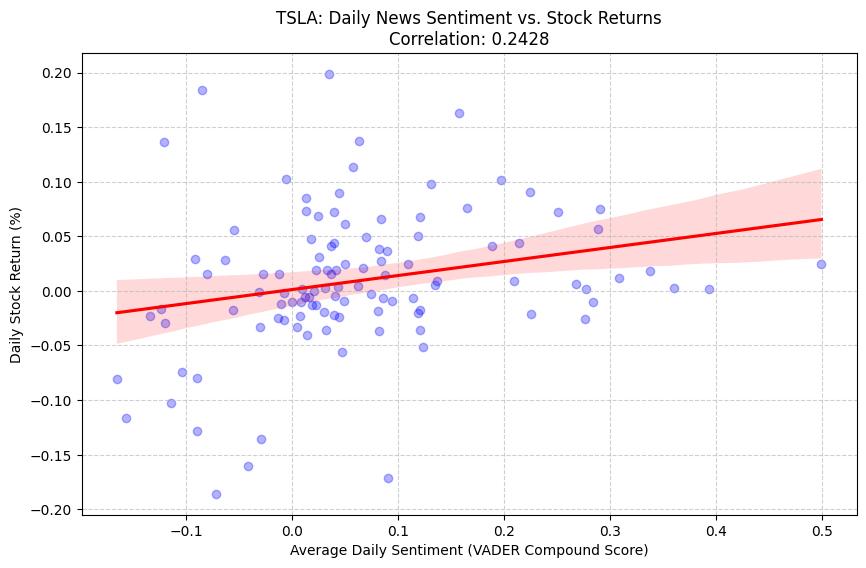

In [10]:
plt.figure(figsize=(10, 6))
# Create a regression plot to see the trend
sns.regplot(data=merged_df, x='sentiment', y='Daily_Return', 
            scatter_kws={'alpha':0.3, 'color':'blue'}, 
            line_kws={'color':'red'})

plt.title(f'TSLA: Daily News Sentiment vs. Stock Returns\nCorrelation: {correlation:.4f}')
plt.xlabel('Average Daily Sentiment (VADER Compound Score)')
plt.ylabel('Daily Stock Return (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

What our result means:

    Correlation > 0.1: There is a positive "signal." When news is better, the price tends to go up.

    Correlation < -0.1: An inverse relationship (rare, but interesting!).

    Correlation near 0: The news headlines (or at least VADER's interpretation of them) are not currently driving the stock's daily price movement.